# Global success counts by number of atoms

Aggregate all evaluation results across every model/action pair and
count how many successful structures share the same `num_site` (number of atoms).
Use this notebook when a single, corpus-wide view is needed instead of one plot
per model/action.

In [7]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from utils.dataloader import load_cif_file_from_string

In [14]:
actions = [
    'add_atom_action',
    'change_atom_action',
    'delete_below_atom_action',
    'insert_between_atoms_action',
    'move_atom_action',
    'move_towards_atom_action',
    'remove_atom_action',
    # 'rotate_around_atom_action',
    # 'swap_atoms_action',
]

models = [
    'deepseek_chat',
    'gemini_2_5_pro',
    # 'llama3_70b',
    'qwen3_32B',
    # 'qwen3_14B',
    # 'qwen3_8B',
    # 'qwen3_4B',
    'o3',
    'o4_mini',
]

RESULTS_ROOT = Path('../../results/AtomWorld')
RESULTS_ROOT

WindowsPath('../../results/AtomWorld')

In [15]:
missing_runs = []
parse_failures = []

def resolve_result_folder(model_name: str, action_name: str) -> Path | None:
    base_folder = RESULTS_ROOT / model_name / action_name
    if not base_folder.exists():
        return None
    candidates = [
        path for path in base_folder.iterdir()
        if path.is_dir() and path.name.lower() != "logs"
    ]
    if candidates:
        return max(candidates, key=lambda path: path.stat().st_mtime)
    return base_folder

def log_issue(model: str, action: str, reason: str, **extra):
    issue = {"model": model, "action": action, "reason": reason}
    if extra:
        issue.update(extra)
    missing_runs.append(issue)

def read_csv_if_available(path: Path, model: str, action: str, kind: str) -> pd.DataFrame | None:
    if not path.exists():
        log_issue(model, action, f"missing_{kind}_csv", path=str(path))
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        log_issue(model, action, f"read_failure_{kind}", path=str(path), error=str(exc))
        return None

def safe_num_sites(cif_string: str, model_name: str, action_name: str, row_idx: int):
    try:
        return load_cif_file_from_string(cif_string).num_sites
    except Exception as exc:
        parse_failures.append(
            {
                "model": model_name,
                "action": action_name,
                "row": int(row_idx),
                "error": str(exc),
            }
        )
        return None

def extract_num_sites(df: pd.DataFrame, model_name: str, action_name: str) -> list[int]:
    values = []
    for idx, cif_string in df["input_cif"].items():
        num_sites = safe_num_sites(cif_string, model_name, action_name, idx)
        if num_sites is not None:
            values.append(int(num_sites))
    return values

In [16]:
success_counts = Counter()
attempt_counts = Counter()
failure_counts = Counter()
rows_consumed = 0
failed_rows = 0
runs_processed = 0

for model_name in models:
    for action_name in actions:
        folder = resolve_result_folder(model_name, action_name)
        if folder is None:
            log_issue(model_name, action_name, "folder_not_found")
            continue

        runs_processed += 1
        result_path = folder / f"{action_name}_evaluation_results.csv"
        wrong_path = folder / f"{action_name}_evaluation_wrongs.csv"

        result_df = read_csv_if_available(result_path, model_name, action_name, "results")
        wrong_df = read_csv_if_available(wrong_path, model_name, action_name, "wrongs")

        if result_df is not None:
            if "input_cif" not in result_df:
                log_issue(model_name, action_name, "missing_input_cif_column_results")
            else:
                num_sites = extract_num_sites(result_df, model_name, action_name)
                success_counts.update(num_sites)
                attempt_counts.update(num_sites)
                rows_consumed += len(num_sites)

        if wrong_df is not None:
            if "input_cif" not in wrong_df:
                log_issue(model_name, action_name, "missing_input_cif_column_wrongs")
            else:
                wrong_sites = extract_num_sites(wrong_df, model_name, action_name)
                attempt_counts.update(wrong_sites)
                failure_counts.update(wrong_sites)
                failed_rows += len(wrong_sites)

print(f"Runs processed: {runs_processed}")
print(f"Success rows counted: {rows_consumed}")
print(f"Failed rows counted: {failed_rows}")
print(f"Unique num_site values (any outcome): {len(attempt_counts)}")

D:\AI\PythonProjects\AtomWorldBench\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\AI\PythonProjects\AtomWorldBench\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\AI\PythonProjects\AtomWorldBench\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\AI\PythonProjects\AtomWorldBench\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  str

Runs processed: 35
Success rows counted: 3401
Failed rows counted: 1599
Unique num_site values (any outcome): 53


D:\AI\PythonProjects\AtomWorldBench\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)


In [17]:
summary_rows = []
all_sizes = sorted(set(attempt_counts) | set(success_counts))
for num_site in all_sizes:
    total = attempt_counts.get(num_site, 0)
    success = success_counts.get(num_site, 0)
    failure = total - success
    success_rate = success / total if total else 0.0
    summary_rows.append(
        {
            "num_site": num_site,
            "success_count": success,
            "failure_count": failure,
            "total_count": total,
            "success_rate": success_rate,
        }
    )

success_by_size = pd.DataFrame(summary_rows)
success_by_size.head()

,num_site,success_count,failure_count,total_count,success_rate
0,4,18,2,20,0.900000
1,6,48,12,60,0.800000
2,8,88,32,120,0.733333
3,10,203,37,240,0.845833
4,11,81,19,100,0.810000


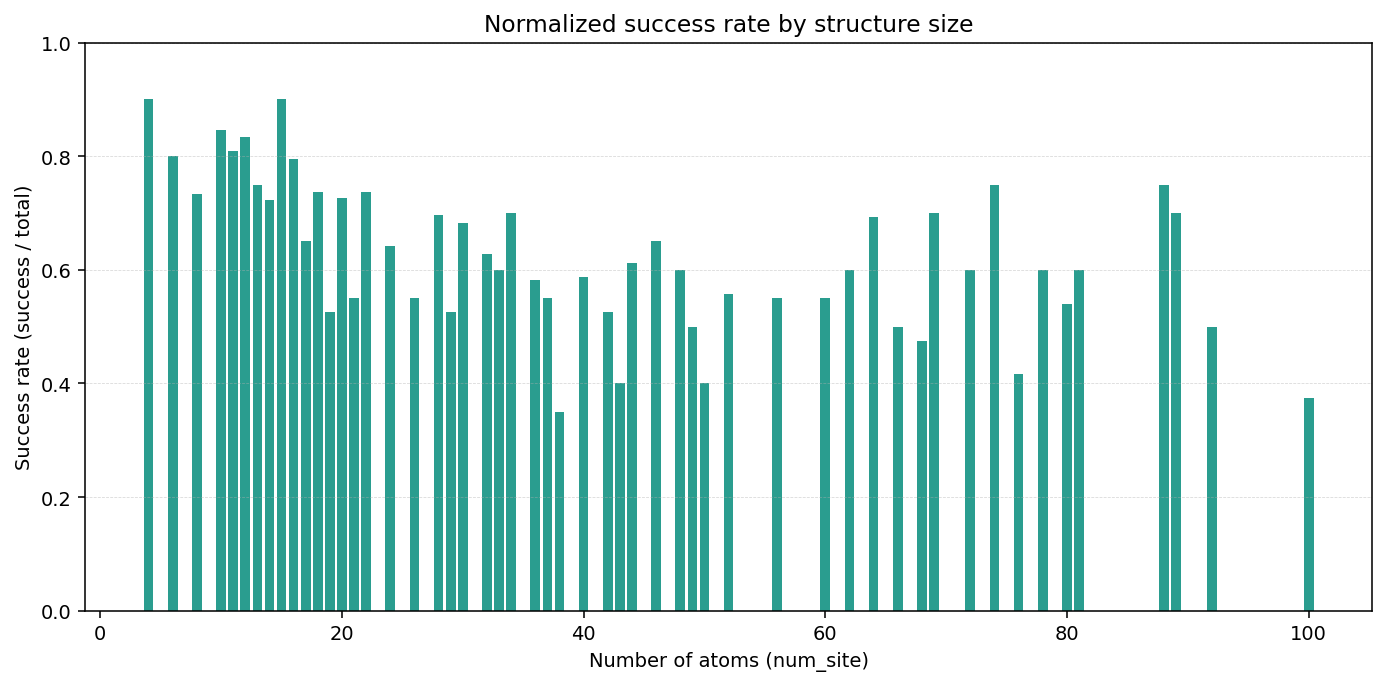

In [18]:
if success_by_size.empty:
    print("No data available to plot.")
else:
    plt.figure(figsize=(10, 5), dpi=140)
    plt.bar(success_by_size["num_site"], success_by_size["success_rate"], color="#2a9d8f")
    plt.xlabel("Number of atoms (num_site)")
    plt.ylabel("Success rate (success / total)")
    plt.title("Normalized success rate by structure size")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

In [13]:
output_path = RESULTS_ROOT / "summaries" / "success_rate_by_num_site.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
success_by_size.to_csv(output_path, index=False)
output_path

WindowsPath('../../results/AtomWorld/summaries/success_rate_by_num_site.csv')

In [ ]:
pd.DataFrame(missing_runs)

In [ ]:
pd.DataFrame(parse_failures)